In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)

Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)


In [3]:
x_train, x_test = x_train / 255.0, x_test / 255.0

model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),  
    tf.keras.layers.Dense(128, activation='relu'),  
    tf.keras.layers.Dense(10, activation='softmax') 
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

D:\Anaconda\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
history = model.fit(x_train, y_train, 
                    epochs=5,
                    validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9271 - loss: 0.2577 - val_accuracy: 0.9554 - val_loss: 0.1503
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9668 - loss: 0.1143 - val_accuracy: 0.9690 - val_loss: 0.1057
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9768 - loss: 0.0794 - val_accuracy: 0.9740 - val_loss: 0.0841
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9814 - loss: 0.0593 - val_accuracy: 0.9651 - val_loss: 0.1148
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9854 - loss: 0.0464 - val_accuracy: 0.9746 - val_loss: 0.0879


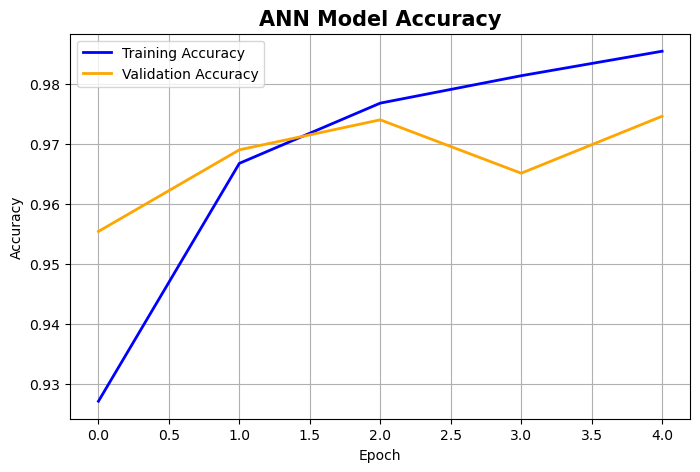

🎯 Final Validation Accuracy: 97.46%


In [5]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'],     label='Training Accuracy',   color='blue',   linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)

plt.title('ANN Model Accuracy', fontsize=15, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

final_acc = history.history['val_accuracy'][-1] * 100
print(f'Final Validation Accuracy: {final_acc:.2f}%')

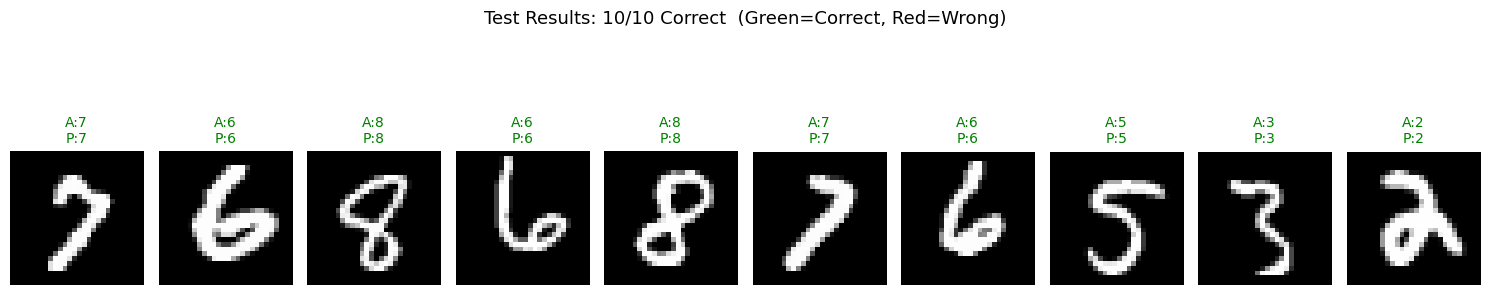

In [6]:
plt.figure(figsize=(15, 4))
correct = 0

for i in range(10):
    idx = np.random.randint(0, len(x_test))
    img = x_test[idx]
    actual = y_test[idx]
    predicted = np.argmax(model.predict(img.reshape(1, 28, 28), verbose=0))
    
    if actual == predicted:
        correct += 1
        color = 'green'
    else:
        color = 'red'
    
    plt.subplot(1, 10, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f'A:{actual}\nP:{predicted}', color=color, fontsize=10)
    plt.axis('off')

plt.suptitle(f'Test Results: {correct}/10 Correct  (Green=Correct, Red=Wrong)', fontsize=13)
plt.tight_layout()
plt.show()

In [7]:
from ipywidgets import FileUpload, Button, Output
from IPython.display import display
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import io

upload = FileUpload(accept='image/*', multiple=False)
btn = Button(description="Predict")
out = Output()

display(upload, btn, out)

def predict_image(b):
    out.clear_output()
    with out:
        if len(upload.value) == 0:
            print("First Upload an image!")
            return
        
        uploaded_file = list(upload.value)[0]
        img_bytes = uploaded_file['content']
        
        img = Image.open(io.BytesIO(img_bytes)).convert("L")
        img = img.resize((28, 28))
        img_array = np.array(img) / 255.0
        
        prediction = model.predict(img_array.reshape(1, 28, 28))
        predicted_label = np.argmax(prediction)
        
        plt.imshow(img_array, cmap='gray')
        plt.title(f"Predicted Number: {predicted_label}")
        plt.show()

btn.on_click(predict_image)

FileUpload(value=(), accept='image/*', description='Upload')

Button(description='Predict', style=ButtonStyle())

Output()

In [8]:
model.save('ann_mnist_model.h5')
print("Model Saved!")

Model Saved!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from ipywidgets import FileUpload, Button, Output
from IPython.display import display
from PIL import Image
import io

model = load_model('ann_mnist_model.h5')
print("Model Loaded Successfully!")

upload = FileUpload(accept='image/*', multiple=False)
btn = Button(description="Predict", button_style='success')
out = Output()
display(upload, btn, out)

def predict_image(b):
    out.clear_output()
    with out:
        if len(upload.value) == 0:
            print("First Upload an image!")
            return
        
        uploaded_file = list(upload.value)[0]
        img_bytes = uploaded_file['content']
        
        img = Image.open(io.BytesIO(img_bytes)).convert("L")
        img = img.resize((28, 28))
        img_array = np.array(img) / 255.0
        
        prediction = model.predict(img_array.reshape(1, 28, 28))
        predicted_label = np.argmax(prediction)
        
        plt.imshow(img_array, cmap='gray')
        plt.title(f"Predicted Number: {predicted_label}")
        plt.show()
btn.on_click(predict_image)

Model Loaded Successfully!


FileUpload(value=(), accept='image/*', description='Upload')

Button(button_style='success', description='Predict', style=ButtonStyle())

Output()